## Linear Regression using Scikit-Learn

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from lab_utils_multi import load_house_data
from lab_utils_common import dlc
np.set_printoptions(precision=2)
plt.style.use("./deeplearning.mplstyle")

In [2]:
X_train, y_train = load_house_data()
X_features = ['size(sqft)', 'bedrooms', 'floor', 'age']

In [3]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_train)

print(f"peak to peak range by column in raw X = {np.ptp(X_train, axis = 0)}")
print(f"peak to peak range by column in nirmalized X = {np.ptp(X_norm, axis = 0)}")

peak to peak range by column in raw X = [2.41e+03 4.00e+00 1.00e+00 9.50e+01]
peak to peak range by column in nirmalized X = [5.85 6.14 2.06 3.69]


In [14]:
sgdr = SGDRegressor(max_iter=1000)
sgdr.fit(X_norm, y_train)
print(sgdr)
print(f"number of iterations complete = {sgdr.n_iter_}, number of weights = {sgdr.t_}")

SGDRegressor()
number of iterations complete = 107, number of weights = 10594.0


In [13]:
b_norm = sgdr.intercept_
w_norm = sgdr.coef_
print(f"model parameters:                   w: {w_norm}, b:{b_norm}")
print( "model parameters from previous lab: w: [110.56 -21.27 -32.71 -37.97], b: 363.16")

model parameters:                   w: [109.77 -20.89 -32.28 -38.11], b:[363.16]
model parameters from previous lab: w: [110.56 -21.27 -32.71 -37.97], b: 363.16


In [16]:
y_pred_sgd = sgdr.predict(X_norm)
y_pred = np.dot(X_norm, w_norm) + b_norm
print(f"prediction using np.dot or sgd.predict match = {(y_pred_sgd == y_pred).all()}")
print(f"prediction on tranning set \n{y_pred[:4]}")
print(f"target value \n{y_train[:4]}")



prediction using np.dot or sgd.predict match = False
prediction on tranning set 
[295.21 485.79 389.63 491.95]
target value 
[300.  509.8 394.  540. ]


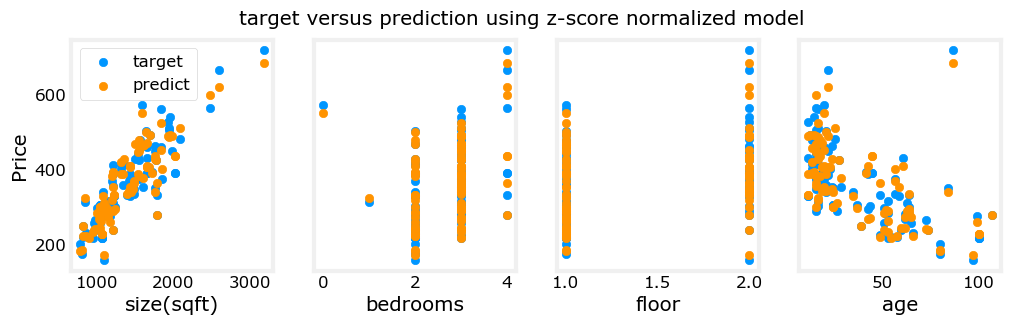

In [18]:
# plot predictions and targets vs original features    
fig,ax=plt.subplots(1,4,figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i],y_train, label = 'target')
    ax[i].set_xlabel(X_features[i])
    ax[i].scatter(X_train[:,i],y_pred,color=dlc["dlorange"], label = 'predict')
ax[0].set_ylabel("Price"); ax[0].legend()
fig.suptitle("target versus prediction using z-score normalized model")
plt.show()